**Step 0 :- Data Collection** https://www.kaggle.com/datasets/nitinchoudhary012/algerian-forest-fires-dataset 

## Algerian Forest Fires Dataset 
Data Set Information:

The dataset includes 244 instances that regroup a data of two regions of Algeria,namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attribues and 1 output attribue (class)
The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.

### Attribute Information:

`1. Date :` (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations

`2. Temp :` temperature noon (temperature max) in Celsius degrees: 22 to 42

`3. RH :` Relative Humidity in %: 21 to 90

`4. Ws :`Wind speed in km/h: 6 to 29

`5. Rain:` total day in mm: 0 to 16.8
FWI Components

`6. Fine Fuel Moisture Code (FFMC) index from the FWI system:` 28.6 to 92.5

`7. Duff Moisture Code (DMC) index from the FWI system:` 1.1 to 65.9

`8. Drought Code (DC) index from the FWI system:` 7 to 220.4

`9. Initial Spread Index (ISI) index from the FWI system:` 0 to 18.5

`10. Buildup Index (BUI) index from the FWI system:` 1.1 to 68

`11. Fire Weather Index (FWI) Index:` 0 to 31.1

`12. Classes:` two classes, namely Fire and not Fire

### Step 1 :- Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

### Step 2 :- Load dataset / Read dataset

In [3]:
df = pd.read_csv('Data/Algerian_forest_fires_dataset.csv') 

In [4]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


### Step 3 :- Data Overview 

In [5]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [7]:
print(f"Numbers of Rows  :- {df.shape[0]}")
print(f"Number of Columns:- {df.shape[1]}")

Numbers of Rows  :- 247
Number of Columns:- 14


### Stpe 4 :- Data Cleaning

In [8]:
# Missing Values

df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

The dataset is converted into two sets based on Region from 122th index, we can make a new column based on the Region

1 : "Bejaia Region Dataset"

2 : "Sidi-Bel Abbes Region Dataset"

Add new column with region

In [9]:
# Missing Values

df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [10]:
df.loc[:123,"Region"] = 0
df.loc[123:,"Region"] = 1
df.head(136)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0
5,6,6,2012,31,67,14,0,82.6,5.8,22.2,3.1,7,2.5,fire,0.0
6,7,6,2012,33,54,13,0,88.2,9.9,30.5,6.4,10.9,7.2,fire,0.0
7,8,6,2012,30,73,15,0,86.6,12.1,38.3,5.6,13.5,7.1,fire,0.0
8,9,6,2012,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,not fire,0.0
9,10,6,2012,28,79,12,0,73.2,9.5,46.3,1.3,12.6,0.9,not fire,0.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       247 non-null    float64
dtypes: float64(1), object(14)
memory usage: 29.1+ KB


In [12]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [13]:
df[['Region']] = df[['Region']].astype(int)

In [14]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [15]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
Region         0
dtype: int64

In [16]:
# Removing the Null Values

df = df.dropna().reset_index(drop=True)

In [17]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [18]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [19]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [20]:
##remove the 122nd row
df=df.drop(122).reset_index(drop=True)

In [21]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [22]:
## fix spaces in columns names
df.columns=df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4   RH           243 non-null    object
 5   Ws           243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int32 
dtypes: int32(1), object(14)
memory usage: 27.7+ KB


### Changes the required columns as integer data type

In [24]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [25]:
df[['month','day','year','Temperature','RH','Ws']]=df[['month','day','year','Temperature','RH','Ws']].astype(int)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int32 
 1   month        243 non-null    int32 
 2   year         243 non-null    int32 
 3   Temperature  243 non-null    int32 
 4   RH           243 non-null    int32 
 5   Ws           243 non-null    int32 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int32 
dtypes: int32(7), object(8)
memory usage: 22.0+ KB


In [27]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


### Changing the other columns to float data datatype

In [28]:
Objects = [features for features in df.columns if df[features].dtypes=='O']

In [29]:
Objects

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [30]:
for i in Objects:
    if i != 'Classes':
        df[i] = df[i].astype(float)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int32  
 1   month        243 non-null    int32  
 2   year         243 non-null    int32  
 3   Temperature  243 non-null    int32  
 4   RH           243 non-null    int32  
 5   Ws           243 non-null    int32  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int32  
dtypes: float64(7), int32(7), object(1)
memory usage: 22.0+ KB


In [32]:
Objects

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,243.0,15.761317,8.842552,1.0,8.00,16.0,23.00,31.0
month,243.0,7.502058,1.114793,6.0,7.00,8.0,8.00,9.0
year,243.0,2012.000000,0.000000,2012.0,2012.00,2012.0,2012.00,2012.0
Temperature,243.0,32.152263,3.628039,22.0,30.00,32.0,35.00,42.0
RH,243.0,62.041152,14.828160,21.0,52.50,63.0,73.50,90.0
Ws,243.0,15.493827,2.811385,6.0,14.00,15.0,17.00,29.0
Rain,243.0,0.762963,2.003207,0.0,0.00,0.0,0.50,16.8
FFMC,243.0,77.842387,14.349641,28.6,71.85,83.3,88.30,96.0
DMC,243.0,14.680658,12.393040,0.7,5.80,11.3,20.80,65.9
DC,243.0,49.430864,47.665606,6.9,12.35,33.1,69.10,220.4


In [34]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [35]:
# Saving the Cleaned Dataset

df.to_csv('Data/Algerian_forest_fires_cleaned_dataset.csv',index=False)

### Exploratory Data Analysis

In [36]:
## drop day,month and year
df_copy = df.copy()

In [37]:
df_copy.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [38]:
## categories in classes
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [39]:
## Encoding of the categories in classes
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)

In [40]:
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [41]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


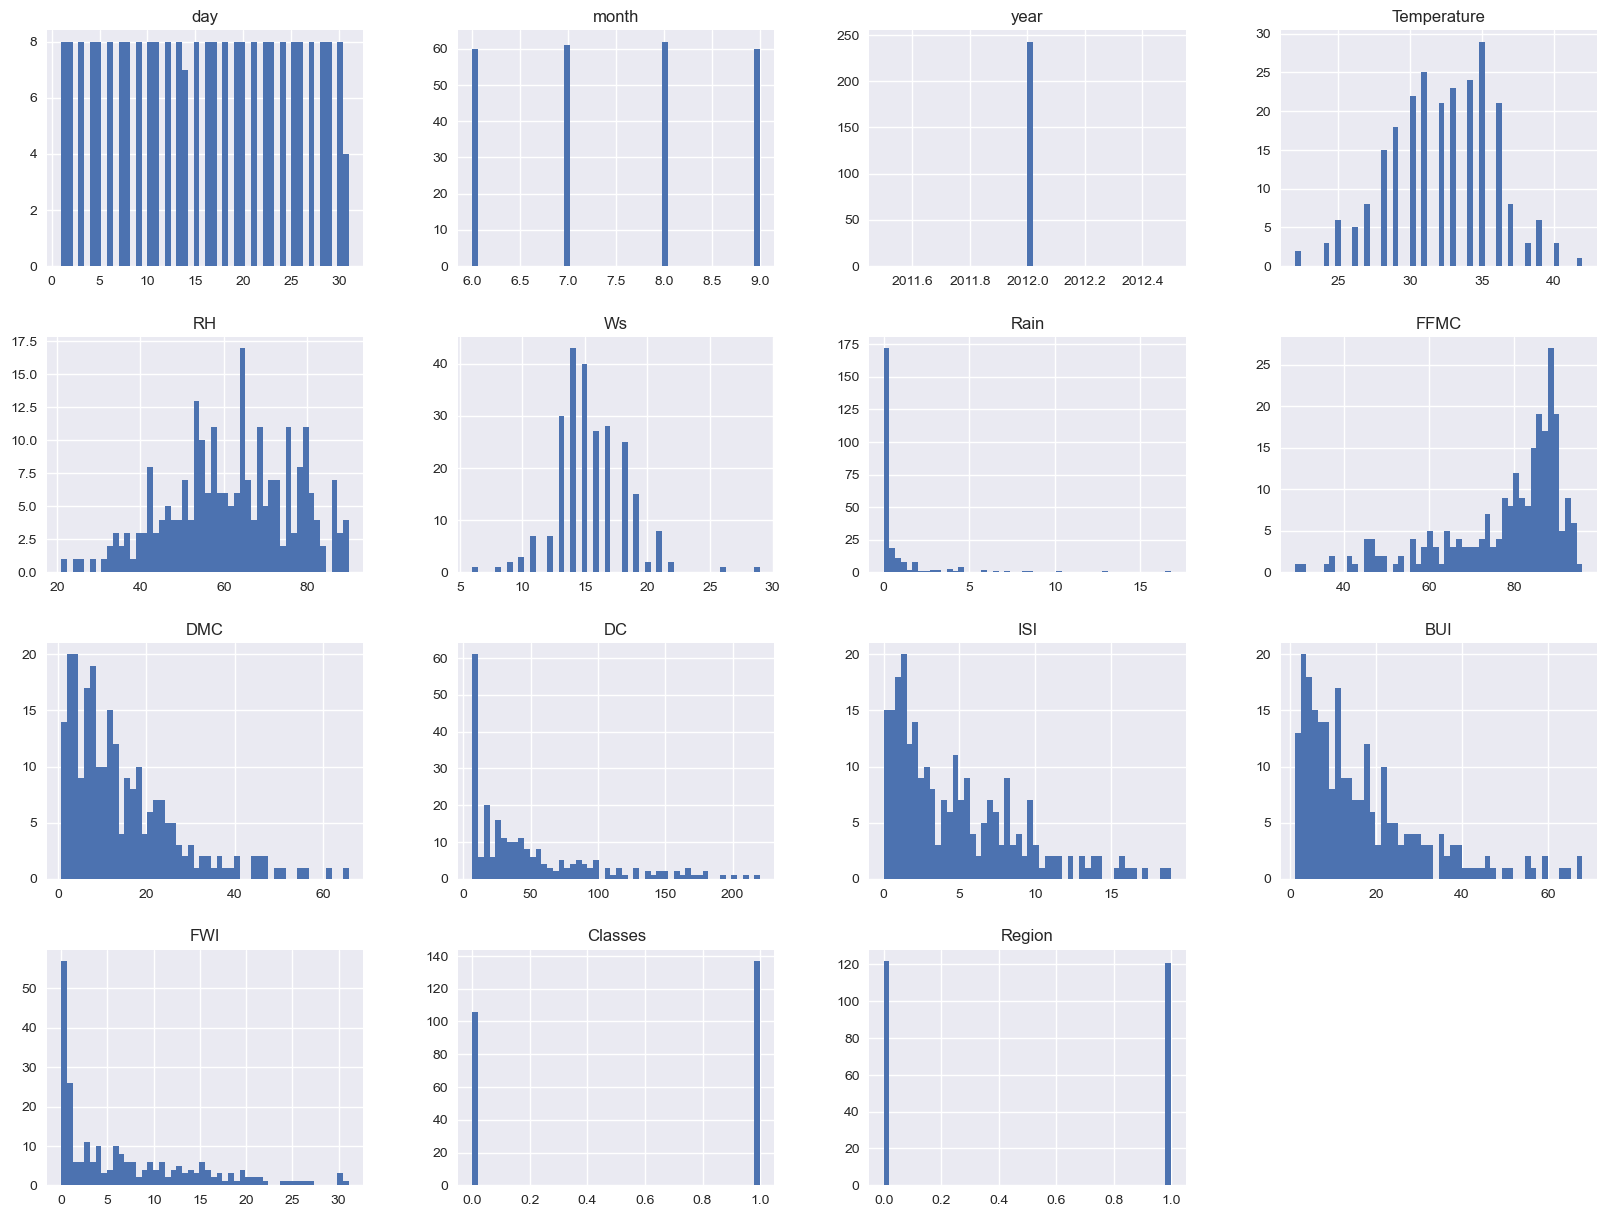

In [42]:
## Plot desnity plot for all features

plt.style.use('seaborn-v0_8')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

### 1. **Temperature**:
   - **Distribution**: The histogram for `Temperature` appears to show a fairly uniform distribution with peaks at certain temperature values (around 30-35°C). It suggests that the data is spread across a range of temperatures, with some frequent values in the mid-range.
   - **Interpretation**: The temperature in this dataset seems to range from about 22°C to 42°C, with a concentration in the 30-35°C range, which might indicate normal temperatures for the region or time of year under study.

### 2. **RH (Relative Humidity)**:
   - **Distribution**: The histogram for `RH` shows a roughly normal distribution, with a concentration of values between 40 and 70%, and a long tail toward higher values.
   - **Interpretation**: This suggests moderate relative humidity levels are common, with some rare high-humidity occurrences (possibly due to specific weather conditions). RH plays a key role in fire behavior, so this could be important for fire risk analysis.

### 3. **Ws (Wind Speed)**:
   - **Distribution**: The `Ws` histogram has a few distinct peaks, indicating periods of high wind speeds. However, most of the data appears to be in the lower range (around 5-15 km/h).
   - **Interpretation**: Wind speed is relatively low for most of the data, but there are outliers with higher wind speeds. This could affect fire behavior, as strong winds can spread fire faster.

### 4. **Rain**:
   - **Distribution**: The `Rain` feature shows a skewed distribution with most of the data concentrated at lower values (around 0-5 mm), and a few high-value outliers.
   - **Interpretation**: This suggests that rainfall is relatively sparse, and only occasionally are there large rainfall events. This could indicate dry conditions, which may contribute to fire risk.

### 5. **FFMC (Fine Fuel Moisture Code)**:
   - **Distribution**: The histogram for `FFMC` shows a distribution skewed toward lower values, with a peak around 60.
   - **Interpretation**: FFMC is a measure of the moisture content in fine fuels (like grass). A low FFMC indicates relatively dry fuels, which can enhance fire behavior.

### 6. **DMC (Duff Moisture Code)**:
   - **Distribution**: `DMC` has a somewhat uniform distribution, with values ranging from 0 to 50.
   - **Interpretation**: The DMC represents moisture in larger fuels like leaves and branches. Higher DMC values can indicate more moisture in duff, which reduces the likelihood of fire spread.

### 7. **DC (Drought Code)**:
   - **Distribution**: The `DC` histogram is skewed, with many data points in the lower range (0-50), but some outliers reach up to 150-200.
   - **Interpretation**: The Drought Code tracks the moisture content of deep organic matter in the soil. A higher DC could mean that the ground moisture is lower, which is significant for fire behavior, as dry conditions encourage fire spread.

### 8. **FWI (Fire Weather Index)**:
   - **Distribution**: The histogram for `FWI` is heavily skewed toward the lower values (around 0-5), with a few higher values that represent extreme fire conditions.
   - **Interpretation**: This indicates that fire weather is mostly low risk, but there are occasional extreme fire weather events, which could contribute to wildfires.

### 9. **ISI (Initial Spread Index)**:
   - **Distribution**: The `ISI` histogram shows a distribution similar to `FWI`, with most values concentrated between 0-5 and a few outliers.
   - **Interpretation**: The ISI indicates the rate of fire spread under current weather conditions. A low ISI suggests that fire spread is slow, while higher values indicate faster spread. The dataset seems to have more slow-spreading fires with occasional high-speed fires.

### 10. **BUI (Buildup Index)**:
   - **Distribution**: The histogram for `BUI` shows a distribution where most values are between 0 and 30, with some higher values.
   - **Interpretation**: The BUI tracks the amount of fuel available for combustion. Lower values suggest less fuel buildup, which is favorable in preventing large fires.

### 11. **Classes**:
   - **Distribution**: The `Classes` feature seems to have a binary or categorical distribution with values near 0 and 1, indicating different fire risk categories.
   - **Interpretation**: This feature is likely categorizing fire risk (e.g., low risk = 0, high risk = 1). The distribution shows how common each class is, and it can help in understanding the relationship between the weather conditions and fire severity.

### 12. **Region**:
   - **Distribution**: The `Region` histogram seems to have a narrow distribution, likely indicating different geographical areas or zones.
   - **Interpretation**: The data could be separated into regions with specific characteristics, such as weather or fire behavior tendencies, and this feature can be important in understanding localized fire risk.

---

### General Insights:
- Many of the features (such as `Temperature`, `RH`, `Ws`, and `FFMC`) show skewed distributions, which are common in real-world data. Skewed data might need transformation or special handling before being used in modeling.
- The relatively sparse occurrence of extreme values for many features (like `Rain`, `FFMC`, `DMC`) suggests that the data captures typical conditions most of the time, with occasional outliers representing extreme events.
- The `Classes` feature, being binary, likely indicates a classification between fire risk levels, which could be useful for predictive modeling.


In [43]:
## Percentage for Pie Chart
percentage=df_copy['Classes'].value_counts(normalize=True)*100
percentage

Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64

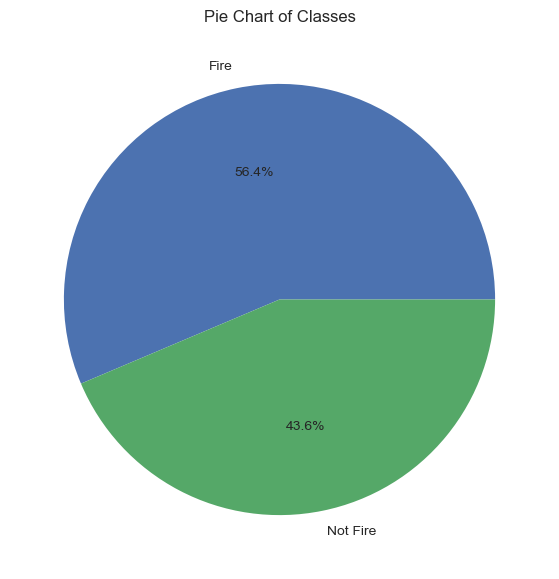

In [44]:
# plotting piechart
classlabels=["Fire","Not Fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title("Pie Chart of Classes")
plt.show()

### Correlation

In [45]:
df_copy.corr()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
day,1.000000,-0.000369,NaN,0.097227,-0.076034,0.047812,-0.112523,0.224956,0.491514,0.527952,0.180543,0.517117,0.350781,0.202840,0.000821
month,-0.000369,1.000000,NaN,-0.056781,-0.041252,-0.039880,0.034822,0.017030,0.067943,0.126511,0.065608,0.085073,0.082639,0.024004,0.001857
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,0.097227,-0.056781,NaN,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.076034,-0.041252,NaN,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,0.047812,-0.039880,NaN,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.112523,0.034822,NaN,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.224956,0.017030,NaN,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.491514,0.067943,NaN,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.527952,0.126511,NaN,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734


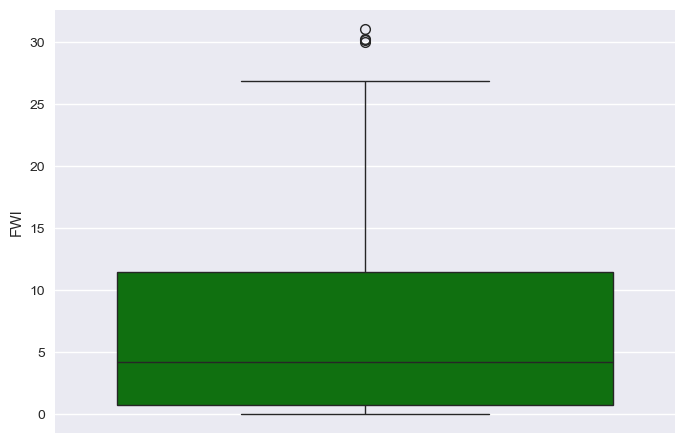

In [46]:
## Box Plots
sns.boxplot(df['FWI'],color='green')
plt.show()

In [47]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


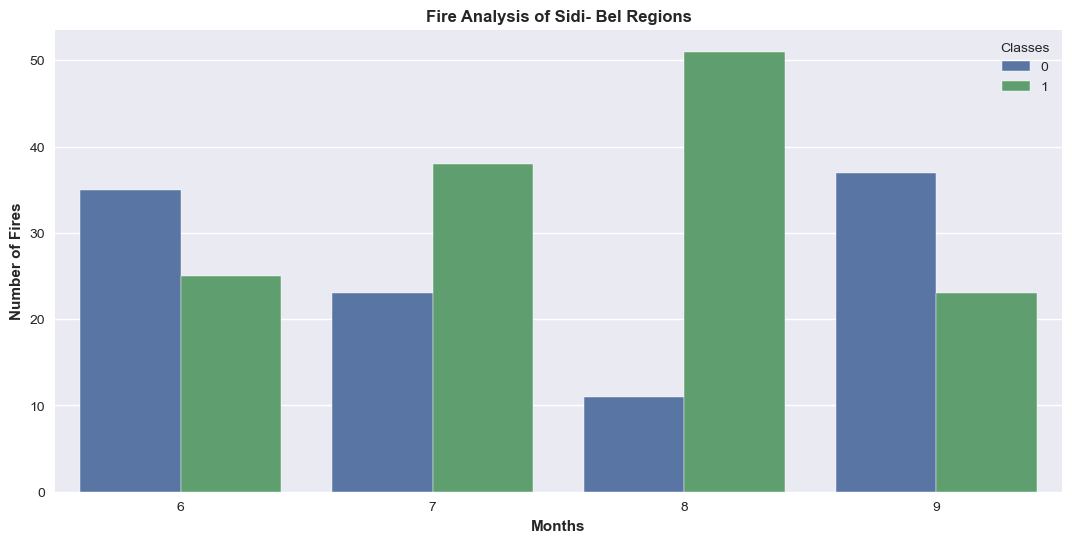

In [48]:
## Monthly Fire Analysis
dftemp=df.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df_copy)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Sidi- Bel Regions",weight='bold')
plt.show()

### Key Observations:

1. **Fire Distribution**:
   - The months shown in the plot are **June (6)**, **July (7)**, **August (8)**, and **September (9)**.
   - In **June** and **July**, the number of fires (green bars) is relatively lower, with more occurrences of "not fire" (blue bars).
   - **August (8)** shows a clear peak in fire incidents, with the green bar significantly higher than the blue bar. This indicates that August experienced the most fire events, which is likely the peak fire season for this region.
   - In **September (9)**, the number of fires drops again, and the "not fire" cases (blue bars) are more frequent than the "fire" cases (green bars).

2. **Insight into Fire Occurrence**:
   - The graph clearly shows that **August** is the month with the most frequent fires, which is common in many regions due to the combination of hotter temperatures, lower humidity, and potentially less rainfall.
   - The **June and July** months have fewer fire occurrences, suggesting a lower fire risk or less favorable conditions for fire spread.
   - **September** has a drop in fire occurrences, possibly due to improved weather conditions (higher rainfall, lower temperatures, or increased humidity).

### Conclusion:
- **Seasonality of Fires**: Fire occurrence is seasonal, with a clear peak in **August**, which might be related to weather conditions (such as high temperatures and dry conditions).
- **Fire Management**: Understanding this seasonal variation can help with fire management strategies, as resources can be allocated more effectively in high-risk months like August.


In [49]:
df["Classes"] = np.where(df['Classes'].str.contains('not fire'),'not fire','fire')

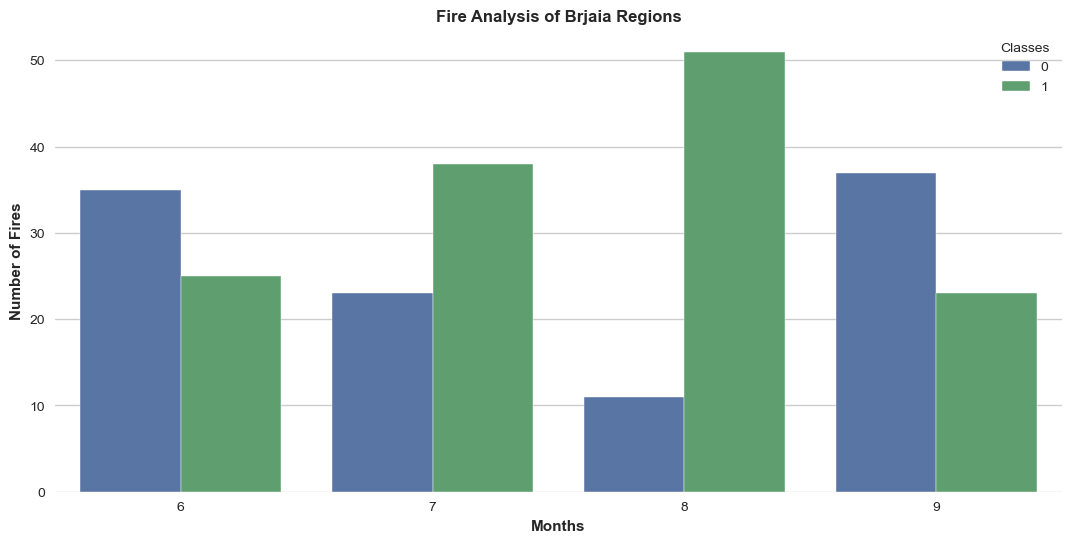

In [50]:
## Monthly Fire Analysis
dftemp=df.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df_copy)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Brjaia Regions",weight='bold')
plt.show()

### Key Observations:

1. **Fire Distribution**:
   - The months shown are **June (6)**, **July (7)**, **August (8)**, and **September (9)**.
   - In **June (6)**, there is a higher number of "not fire" occurrences (blue bars) compared to "fire" occurrences (green bars). This suggests that June experiences fewer fires in this region.
   - **July (7)** shows a similar trend, with "fire" events still less frequent than "not fire" occurrences.
   - **August (8)** is again the month with the highest number of fires, with the green bars (fire) significantly higher than the blue bars (not fire). This supports the pattern that **August** is a peak period for fires.
   - In **September (9)**, the number of fires decreases again, but there is still a noticeable count of fire occurrences, although it drops compared to August.

2. **Insight into Fire Occurrence**:
   - **August (8)** is the peak fire month for **Brjaia Regions**, just like in the Sidi-Bel Regions. This suggests that environmental factors such as temperature, humidity, and vegetation conditions during this month are conducive to higher fire risk.
   - Both **June and July** have relatively fewer fires, although there are still notable occurrences. This may indicate milder conditions that aren’t as prone to fires as August.
   - **September** shows a decrease in fires, which could be due to the region experiencing cooler or wetter conditions, reducing the frequency of fires.

- The trend of **August being the peak month for fires** is consistent across both regions (Sidi-Bel and Brjaia).
- **Fire Risk Management**: This information is valuable for allocating fire-prevention resources during the high-risk months (primarily August), while also noting the relatively lower risk periods in **June, July, and September**.


In [51]:
## drop day,month and year
df_copy = df_copy.drop(['day','month','year'],axis=1)

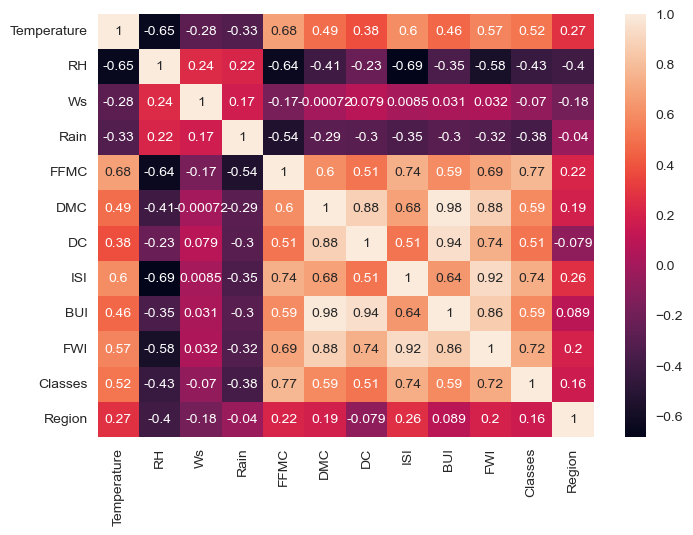

In [52]:
sns.heatmap(df_copy.corr(),annot=True)
plt.show()

### Key Observations:

1. **Temperature & FFMC**: 
   - There is a **strong positive correlation (0.68)** between `Temperature` and `FFMC` (Fine Fuel Moisture Code), indicating that as temperature increases, the moisture in fine fuels tends to decrease, which is expected because higher temperatures tend to dry out fuels.

2. **Temperature & RH (Relative Humidity)**:
   - The **negative correlation (-0.65)** between `Temperature` and `RH` shows that as temperature increases, relative humidity tends to decrease. This makes sense because warmer air holds less moisture.

3. **Wind Speed (Ws) & Rain**:
   - The correlation between `Ws` (wind speed) and `Rain` is **weakly positive (0.17)**, meaning that wind speed has a slight tendency to increase with rainfall, though the relationship isn't strong.

4. **FFMC & DMC**:
   - The **strong positive correlation (0.88)** between `FFMC` and `DMC` suggests that fine fuels and larger fuels (duff) are similarly affected by moisture content, as both codes measure moisture but at different fuel depths.

5. **Classes & Other Features**:
   - The `Classes` feature (likely representing fire risk) shows strong positive correlations with `FFMC`, `DMC`, `ISI`, `FWI`, and `BUI`, which suggests that the fire risk classification is highly dependent on these features, especially the moisture-related indices and fire spread indices.
   - The correlation with `Temperature` is **negative (-0.43)**, suggesting that as temperature increases, the likelihood of certain fire risk classes decreases, possibly because of the way other factors (like humidity) interact with temperature.

6. **Region**:
   - The `Region` feature shows weak correlations with most other features, suggesting that the geographical area might not have a strong direct relationship with other variables in this dataset.

### Insights:
- **Fire Risk Prediction**: Features such as `FFMC`, `DMC`, `FWI`, and `BUI` are highly correlated with `Classes`, which indicates they are likely important for predicting fire risk.
- **Temperature-Humidity Dynamics**: The negative correlation between `Temperature` and `RH` suggests that higher temperatures might coincide with lower humidity, which could be a contributing factor to fire behavior.
- **Wind's Role**: The correlation between wind speed (`Ws`) and other features is not very strong, but wind can still be a critical factor in fire spread, especially in extreme conditions.

### Conclusion:
- **Temperature** and moisture-related indices such as **FFMC** and **DMC** are critical factors influencing fire occurrence.
- **August** stands out as the month with the highest fire incidents in both **Sidi-Bel** and **Brjaia Regions**, which should inform **seasonal fire risk management** strategies.
- Understanding the relationship between **wind speed**, **rain**, and other features is essential for developing a comprehensive fire prediction model.
- To reduce fire risk, particularly during high-risk months, early interventions such as fire prevention campaigns, weather monitoring, and rapid response mechanisms should be put in place.